# Dec2Vec

- 매개변수 

| 매개변수            | 기본값            | 설명                                        |
| --------------- | -------------- | ----------------------------------------- |
| **documents**   | None           | `TaggedDocument` 객체 리스트 (`words`, `tags`) |
| **vector_size** | 100            | 문서 임베딩 차원 수                               |
| **window**      | 5              | 컨텍스트 윈도우 크기 (좌·우 단어 범위)                   |
| **min_count**   | 5              | 학습에 포함할 최소 단어 등장 빈도                       |
| **dm**          | 1              | 학습 알고리즘: 1 → PV-DM / 0 → PV-DBOW          |
| **dm_mean**     | 0              | PV-DM에서 컨텍스트 평균 사용 여부(1: 평균, 0: 합산)       |
| **dm_concat**   | 0              | PV-DM에서 컨텍스트 벡터 + 문서 벡터 결합 , 차원이 급격히 증가               |
| **dbow_words**  | 0              | PV-DBOW 사용 시 단어 벡터도 동시에 학습할지 여부(Skip_gram과 흡사랑 방법)           |
| **epochs**      | 5 (또는 훈련 시 지정) | 학습 반복 횟수                                  |
| **alpha**       | 0.025          | 초기 학습률                                    |
| **min_alpha**   | 0.0001         | 최소 학습률(감소 종료값)                            |
| **negative**    | 5              | 네거티브 샘플링 개수 (0 → off)                     |
| **hs**          | 0              | 1 → Hierarchical Softmax 사용               |
| **sample**      | 1e-3           | 단어 다운샘플링 임계값                              |
| **workers**     | 3              | 병렬 처리 스레드 수                               |
| **epochs**      | 5              | 전체 학습 반복 수                                |
| **seed**        | 0              | 난수 시드(재현성용)                               |

----

- 속성

| 속성                          | 설명                              |
| --------------------------- | ------------------------------- |
| **`model.dv`**              | 학습된 문서 벡터(Document Vectors) 저장소 |
| **`model.wv`**              | 학습된 단어 벡터(Word Vectors) 저장소     |
| **`model.docvecs`**         | `model.dv` 의 이전 이름(하위 호환)       |
| **`model.vector_size`**     | 임베딩 차원 수                        |
| **`model.epochs`**          | 실제 학습 반복 횟수                     |
| **`model.window`**          | 컨텍스트 윈도우 크기                     |
| **`model.corpus_count`**    | 전체 문서 개수                        |
| **`model.trainables`**      | 학습 가능한 내부 파라미터 구조체              |
| **`model.wv.index_to_key`** | 단어 사전(key) 리스트                  |
| **`model.dv.index_to_key`** | 문서 ID(tag) 리스트                  |

----

- 메서드

| 메서드                                    | 사용 예시                                                                              | 설명                        |
| -------------------------------------- | ---------------------------------------------------------------------------------- | ------------------------- |
| **`build_vocab()`**                    | `model.build_vocab(tagged_docs)`                                                   | 말뭉치로 단어/문서 사전 구성          |
| **`train()`**                          | `model.train(tagged_docs, total_examples=model.corpus_count, epochs=model.epochs)` | 사전 구축 후 직접 학습 수행          |
| **`infer_vector()`**                   | `model.infer_vector(tokens, epochs=50, alpha=0.01)`                                | 새 문장 벡터 추론 (학습된 단어 벡터 고정) |
| **`save()` / `load()`**                | `model.save("m.model")` / `Doc2Vec.load("m.model")`                                | 모델 저장 및 불러오기              |
| **`delete_temporary_training_data()`** | `model.delete_temporary_training_data(keep_doctags_vectors=True)`                  | 학습 후 임시 메모리 제거(경량화)       |
| **`most_similar()`**                   | `model.dv.most_similar("DOC_0")`                                                   | 특정 문서와 유사한 문서 ID 리스트 반환   |
| **`similarity_unseen_docs()`**         | `Doc2Vec.similarity_unseen_docs(model, doc1, doc2)`                                | 두 미학습 문장의 의미 유사도 계산       |
| **`get_latest_training_loss()`**       | `model.get_latest_training_loss()`                                                 | 최신 학습 loss 조회             |

- build_vocab(), train() 함수를 이용하여 수동을 학습이 가능 
- 일반적으로는 객체 생성 시 학습을 하지만 수동으로 학습이 가능 
- 학습된 모델에 두개의 함수를 이용시 증분 학습이 가능

    - new_docs = [TaggedDocument(["새로운", "문장"], ["DOC_10"])]
    - model.build_vocab(new_docs, update=True)
    - model.train(new_docs, total_examples=model.corpus_count, epochs=model.epochs)

In [1]:
# ===============================
# KOMORAN 형태소 + Doc2Vec 샘플
# ===============================

# !pip install gensim==4.3.2 konlpy==0.6.0 JPype1==1.5.0

from konlpy.tag import Komoran
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
import random


In [2]:

# -------------------------------
# 1) 샘플 데이터
#    (실전에서는 고객문의/리뷰/뉴스 등으로 교체)
# -------------------------------
docs = [
    "나는 커피를 정말 좋아한다.",
    "오늘 아침에 에스프레소 두 잔을 마셨다.",
    "카페라떼가 제일 맛있다고 생각해.",
    "나는 차를 더 자주 마신다.",
    "녹차를 마시면 기분이 편안해진다.",
    "홍차는 향이 깊고 고급스러운 느낌이야.",
    "카페에서 책 읽는 시간이 너무 좋다.",
    "허브티도 몸에 좋은 것 같아.",
]


In [3]:

# -------------------------------
# 2) KOMORAN 토크나이저
#    - 불용어 제거
#    - 품사 필터링(명사/동사/형용사/일부 부사)
#    - 필요 시 표제화(동사/형용사 어간 사용)
# -------------------------------
komoran = Komoran()

# 간단 불용어 예시 (도메인에 맞게 확장 권장)
STOPWORDS = set(["하다", "되다", "이다", "것", "수", "거"])

# 사용할 품사 태그(주요 의미어 위주)
# NNG/NNP: 일반/고유 명사, VV: 동사 어간, VA: 형용사 어간, MAG: 일반 부사, XR: 어근
KEEP_POS = set(["NNG", "NNP", "VV", "VA", "MAG", "XR"])

def normalize(text: str) -> str:
    # 이모지/특수문자 간단 정리
    text = re.sub(r"[^가-힣0-9a-zA-Z\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_komoran(text: str, use_only_nouns: bool=False):
    text = normalize(text)
    if use_only_nouns:
        # 명사만 사용할 경우(간단/빠름, 의미 손실 가능)
        tokens = komoran.nouns(text)
    else:
        # 품사 기반 필터링
        pos = komoran.pos(text, join=False)
        tokens = []
        for morph, tag in pos:
            if tag in KEEP_POS:
                # VV/VA는 어간이므로 그대로 사용(필요시 '다' 붙이기 옵션 가능)
                # 예: if tag in ("VV","VA"): morph = morph + "다"
                if morph not in STOPWORDS and len(morph) > 1:
                    tokens.append(morph)
    return tokens


In [4]:

# 토큰화 진행
tokenized_docs = [tokenize_komoran(d) for d in docs]

# -------------------------------
# 3) TaggedDocument 생성 (문장 ID 부여)
# -------------------------------
# tagged = [TaggedDocument(words=toks, tags=[f"DOC_{i}"]) 
#           for i, toks in enumerate(tokenized_docs)]
tagged = []
for i, toks in enumerate(tokenized_docs):
    tagged.append(
        TaggedDocument(words=toks, tags=[f"DOC_{i}"])
    )
# -------------------------------
# 4) 재현성 고정
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -------------------------------
# 5) Doc2Vec 학습
#    - dm=1: PV-DM(권장), dm=0: DBOW
#    - dm_mean=1: 컨텍스트 평균(안정적)
# -------------------------------
model = Doc2Vec(
    documents=tagged,
    vector_size=128,
    window=5,
    min_count=1,   # 실전 코퍼스는 3~5 권장
    workers=4,
    dm=1,
    dm_mean=1,
    negative=5,
    epochs=60,
    seed=SEED,
)

print("문서 벡터 수:", len(model.dv))


문서 벡터 수: 8


In [5]:

# -------------------------------
# 6) 문장 간 유사도 확인
# -------------------------------
def print_similarities(doc_id: int):
    base_vec = model.dv[f"DOC_{doc_id}"]
    mat = np.vstack([model.dv[f"DOC_{i}"] for i in range(len(docs))])
    sims = cosine_similarity([base_vec], mat)[0]
    order = sims.argsort()[::-1]
    print(f"\n[기준 문장] {doc_id}: {docs[doc_id]}")
    for idx in order:
        print(f"  → ({idx}) {docs[idx]}  | cos={sims[idx]:.3f}")

print_similarities(0)  # 0번 문장 기준 유사도



[기준 문장] 0: 나는 커피를 정말 좋아한다.
  → (0) 나는 커피를 정말 좋아한다.  | cos=1.000
  → (7) 허브티도 몸에 좋은 것 같아.  | cos=0.046
  → (1) 오늘 아침에 에스프레소 두 잔을 마셨다.  | cos=0.037
  → (4) 녹차를 마시면 기분이 편안해진다.  | cos=0.037
  → (2) 카페라떼가 제일 맛있다고 생각해.  | cos=0.006
  → (3) 나는 차를 더 자주 마신다.  | cos=-0.013
  → (6) 카페에서 책 읽는 시간이 너무 좋다.  | cos=-0.016
  → (5) 홍차는 향이 깊고 고급스러운 느낌이야.  | cos=-0.065


In [6]:

# -------------------------------
# 7) 새로운 문장 inference
#    - 단어 벡터는 고정, 새 문장 벡터만 최적화
# -------------------------------
new_sentence = "오늘은 카페에서 에스프레소를 마시며 책을 읽었다."
new_tokens = tokenize_komoran(new_sentence)

inferred_vec = model.infer_vector(new_tokens, epochs=100, alpha=0.01)

doc_matrix = np.vstack([model.dv[f"DOC_{i}"] for i in range(len(docs))])
sims = cosine_similarity([inferred_vec], doc_matrix)[0]
order = sims.argsort()[::-1]

print(f"\n[새 문장] {new_sentence}")
for idx in order[:5]:
    print(f"  → ({idx}) {docs[idx]}  | cos={sims[idx]:.3f}")



[새 문장] 오늘은 카페에서 에스프레소를 마시며 책을 읽었다.
  → (5) 홍차는 향이 깊고 고급스러운 느낌이야.  | cos=0.125
  → (3) 나는 차를 더 자주 마신다.  | cos=0.065
  → (4) 녹차를 마시면 기분이 편안해진다.  | cos=0.038
  → (2) 카페라떼가 제일 맛있다고 생각해.  | cos=0.015
  → (1) 오늘 아침에 에스프레소 두 잔을 마셨다.  | cos=0.012


In [7]:
from sklearn.manifold import TSNE

In [8]:
# 6) 문장 벡터 행렬 (n_docs × dim)
X = np.vstack([model.dv[f"DOC_{i}"] for i in range(len(docs))])

# 7) t-SNE로 2D 투영
# - perplexity: (보통 5~50) 데이터 수보다 크게 잡지 않기
# - n_iter: 1000~3000 정도 권장
tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="random",
    max_iter=2000,
    random_state=SEED,
)
X_2d = tsne.fit_transform(X)

In [9]:
import matplotlib.pyplot as plt

In [10]:
plt.rc('font', family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

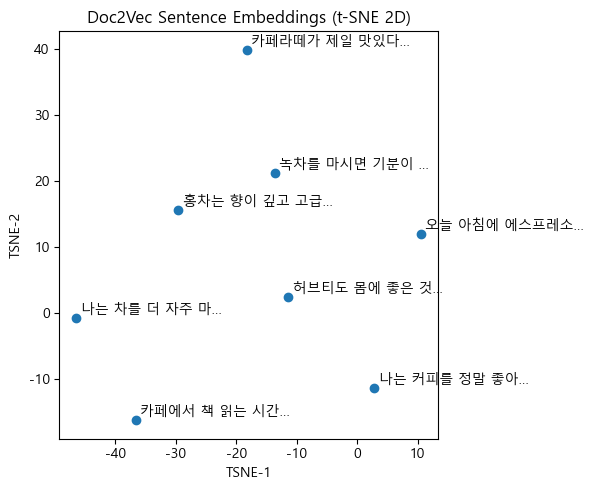

In [11]:
# 8) 시각화 (한 개 플롯, 색상 지정 X)
plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
for i, txt in enumerate(docs):
    # 라벨이 길면 앞부분만 표시 (가독성)
    short = (txt[:12] + "…") if len(txt) > 12 else txt
    plt.annotate(short, (X_2d[i, 0], X_2d[i, 1]), xytext=(3, 3), textcoords="offset points")

plt.title("Doc2Vec Sentence Embeddings (t-SNE 2D)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# 문장 벡터 (Doc2Vec에서 추출)
X = np.vstack([model.dv[f"DOC_{i}"] for i in range(len(docs))])

# 예시 라벨 (1=커피 관련, 0=차 관련)
y = np.array([1,1,1,0,0,0,1,0])

# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 간단한 로지스틱 회귀 모델
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ekfla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [26]:
# ============================================
# KOMORAN + PyTorch Doc2Vec (PV-DM, mean) 샘플
# - 교육/실습용: 작은 코퍼스에서 동작하도록 단순화
# - 중심 아이디어: 문서벡터 + 문맥단어 평균 → 중심단어 예측
# ============================================

import random, collections, re
from typing import List, Tuple

# ---- 0) 형태소 분석기: KOMORAN ----
#  - JDK 설치 + JAVA_HOME 설정 필요
from konlpy.tag import Komoran

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [27]:


# -------------------------------
# 1) 데이터 & 토크나이즈(KOMORAN)
# -------------------------------
docs_raw = [
    "나는 커피를 정말 좋아한다.",
    "오늘 아침에 에스프레소 두 잔을 마셨다.",
    "카페라떼가 제일 맛있다고 생각해.",
    "나는 차를 더 자주 마신다.",
    "녹차를 마시면 기분이 편안해진다.",
    "홍차는 향이 깊고 고급스러운 느낌이야.",
    "카페에서 책 읽는 시간이 너무 좋다.",
    "허브티도 몸에 좋은 것 같아.",
]

komoran = Komoran()

# 간단한 정규화 함수(특수문자/연속공백 정리)
def normalize(text: str) -> str:
    text = re.sub(r"[^가-힣0-9a-zA-Z\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 품사 선택(주요 의미어 위주)
KEEP_POS = {"NNG", "NNP", "VV", "VA", "MAG", "XR"}
STOPWORDS = {"하다", "되다", "이다", "것", "수", "거"}

def tokenize_komoran(text: str) -> List[str]:
    """KOMORAN으로 형태소 분석 → 품사 필터링 → 간단 불용어 제거"""
    text = normalize(text)
    pos = komoran.pos(text, join=False)
    tokens = []
    for morph, tag in pos:
        if tag in KEEP_POS and len(morph) > 1 and morph not in STOPWORDS:
            # VV/VA는 KOMORAN이 어간 형태로 주므로 그대로 사용(원하면 '다' 붙여도 됨)
            tokens.append(morph)
    return tokens

tokenized_docs = [tokenize_komoran(d) for d in docs_raw]
tokenized_docs

[['커피', '정말', '좋아하'],
 ['오늘', '아침', '에스프레소', '마시'],
 ['카페', '제일', '맛있', '생각'],
 ['자주', '마시'],
 ['녹차', '마시', '기분', '편안'],
 ['홍차', '고급', '느낌'],
 ['카페', '시간', '너무'],
 ['허브']]

In [28]:

# -------------------------------
# 2) 어휘/문서 사전 (PAD/UNK 포함)
# -------------------------------
#  - <PAD>: 패딩 혹은 안전한 빈 인덱스
#  - <UNK>: 사전에 없는(OOV) 단어 대체
min_count = 1
# 토큰 데이터에서 단어의 개수를 생성
freq = collections.Counter(w for doc in tokenized_docs for w in doc)
freq


Counter({'마시': 3,
         '카페': 2,
         '커피': 1,
         '정말': 1,
         '좋아하': 1,
         '오늘': 1,
         '아침': 1,
         '에스프레소': 1,
         '제일': 1,
         '맛있': 1,
         '생각': 1,
         '자주': 1,
         '녹차': 1,
         '기분': 1,
         '편안': 1,
         '홍차': 1,
         '고급': 1,
         '느낌': 1,
         '시간': 1,
         '너무': 1,
         '허브': 1})

In [29]:
vocab = ["<PAD>", "<UNK>"] + [w for w, c in freq.items() if c >= min_count]
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
vocab

['<PAD>',
 '<UNK>',
 '커피',
 '정말',
 '좋아하',
 '오늘',
 '아침',
 '에스프레소',
 '마시',
 '카페',
 '제일',
 '맛있',
 '생각',
 '자주',
 '녹차',
 '기분',
 '편안',
 '홍차',
 '고급',
 '느낌',
 '시간',
 '너무',
 '허브']

In [30]:

def encode(words: List[str]) -> List[int]:
    # OOV 단어에 대한 인덱스를 넣을것인가
    return [stoi.get(w, stoi["<UNK>"]) for w in words]

encoded_docs = [encode(doc) for doc in tokenized_docs]
num_docs = len(encoded_docs)
vocab_size = len(vocab)

encoded_docs

[[2, 3, 4],
 [5, 6, 7, 8],
 [9, 10, 11, 12],
 [13, 8],
 [14, 8, 15, 16],
 [17, 18, 19],
 [9, 20, 21],
 [22]]

In [31]:

# -------------------------------
# 3) 학습 샘플 생성 (PV-DM, window 기반)
#    (doc_id, context_ids[], target_id)
# -------------------------------
def build_pvdm_samples(encoded_docs, window = 2):
    samples = []
    for d_id, doc in enumerate(encoded_docs):
        if len(doc) < 2:
            continue
        # center -> 중심 단어 인덱스
        for center in range(len(doc)):
            left = max(0, center - window)
            right = min(len(doc), center + window + 1)
            ctx = [doc[i] for i in range(left, right) if i != center]
            if ctx:
                target = doc[center]
                samples.append((d_id, ctx, target))
                # d_id는 문장의 번호
                # ctx는 주변 단어의 인덱스
                # target은 중심 단어의 인덱스
    return samples

samples = build_pvdm_samples(encoded_docs, window=2)
samples

[(0, [3, 4], 2),
 (0, [2, 4], 3),
 (0, [2, 3], 4),
 (1, [6, 7], 5),
 (1, [5, 7, 8], 6),
 (1, [5, 6, 8], 7),
 (1, [6, 7], 8),
 (2, [10, 11], 9),
 (2, [9, 11, 12], 10),
 (2, [9, 10, 12], 11),
 (2, [10, 11], 12),
 (3, [8], 13),
 (3, [13], 8),
 (4, [8, 15], 14),
 (4, [14, 15, 16], 8),
 (4, [14, 8, 16], 15),
 (4, [8, 15], 16),
 (5, [18, 19], 17),
 (5, [17, 19], 18),
 (5, [17, 18], 19),
 (6, [20, 21], 9),
 (6, [9, 21], 20),
 (6, [9, 20], 21)]

In [32]:
# -------------------------------
# 4) Dataset / DataLoader
# -------------------------------
class PVDMDataset(Dataset):
    def __init__(self, samples, max_ctx: int = 8):
        self.samples = samples
        self.max_ctx = max_ctx  # 문맥이 너무 길면 자르기(단순화)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        d_id, ctx, target = self.samples[idx]
        if len(ctx) > self.max_ctx:
            ctx = ctx[:self.max_ctx]
        return d_id, torch.tensor(ctx, dtype=torch.long), torch.tensor(target, dtype=torch.long)

def collate_fn(batch):
    # 문맥 길이가 다르므로 리스트로 그대로 전달(평균을 낼 것이므로 pad 불필요)
    doc_ids, ctx_lists, targets = zip(*batch)
    return torch.tensor(doc_ids, dtype=torch.long), list(ctx_lists), torch.stack(targets)

dataset = PVDMDataset(samples)
loader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
loader

In [33]:
import torch
import torch.nn as nn

# nn.Embedding(  ) :  단어 ID를 밀집 벡터의 형태로 변환해주는 함수
# 인덱스의 개수 * 차원의 수 만큼의 행렬을 단어별로 구성
# 어휘 크기 5개, 임베딩 차원 3
# 딥러닝에서 자연어를 다룰 때 정수 인덱스 형태의 단어를 벡터로 바꾸는 핵심 기능
emb = nn.Embedding(num_embeddings=5, embedding_dim=3)

# 단어 인덱스 텐서 (예: "나는"=0, "커피"=1)
x = torch.tensor([0, 1, 3])

# 결과: 각 인덱스에 해당하는 벡터를 추출
print(emb(x))

tensor([[-0.8387, -0.8962, -0.2775],
        [ 2.9405,  0.9235, -0.7792],
        [ 1.3341, -0.5271, -2.6619]], grad_fn=<EmbeddingBackward0>)


In [34]:
import torch
import torch.nn as nn

# 5개의 단어, 3차원 임베딩
emb = nn.Embedding(5, 3)

# 초기 가중치 보기 (기본은 Uniform(-√1/num_embeddings, √1/num_embeddings))
print("초기값 (기본):")
print(emb.weight)

# Xavier 방식으로 재초기화
nn.init.xavier_uniform_(emb.weight)
print("\nXavier 초기화 후:")
print(emb.weight)

초기값 (기본):
Parameter containing:
tensor([[-0.4311,  0.2163,  0.7785],
        [ 0.1090, -1.8986, -0.7638],
        [ 0.7030, -0.1394, -0.4001],
        [-0.4871, -0.7071,  1.2414],
        [-0.7419,  1.8570,  0.9935]], requires_grad=True)

Xavier 초기화 후:
Parameter containing:
tensor([[-0.5796,  0.6038,  0.6048],
        [ 0.6840, -0.2218, -0.4091],
        [ 0.2450,  0.3130, -0.0466],
        [ 0.1321,  0.4980,  0.2255],
        [-0.6123,  0.2927,  0.5071]], requires_grad=True)


In [ ]:
# -------------------------------
# 5) 모델 정의 (PV-DM mean)
#    문서벡터 + 문맥단어 평균 → Linear → vocab softmax
# -------------------------------
class Doc2VecPVDM(nn.Module):
    def __init__(self, vocab_size: int, num_docs: int, emb_dim: int = 128):
        super().__init__()
        # 단어별 임베딩 
        self.word_emb = nn.Embedding(vocab_size, emb_dim)
        # 문장별 임베딩
        self.doc_emb  = nn.Embedding(num_docs, emb_dim)
        # 문맥 / 문서 벡터 데이터를 이용하여 단어 확률 분포로 바꿔주는 선형 변환층
        # bias는 doc2vec에서 입력 벡터와 가중치 행렬만으로 사용하기에 절편의 의미인 bias는 사용하지 않음 
        self.proj     = nn.Linear(emb_dim, vocab_size, bias=False)
        # 임베딩 행렬의 초기 값을 적당한 분포로 설정하여 학습이 잘되도록 초기화
        # 자비에르 초기화
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.word_emb.weight)
        nn.init.xavier_uniform_(self.doc_emb.weight)
        nn.init.xavier_uniform_(self.proj.weight)

    def forward(self, doc_ids, ctx_lists):
        """
        doc_ids: (B,)
        ctx_lists: 길이 B 리스트, 각 원소는 (Ci,) 문맥 단어 id 텐서
        return: logits (B, vocab_size)
        """
        device = self.word_emb.weight.device

        # 문서 임베딩 (B, D)
        # 해당 문서 번호의 임베딩 벡터 데이터를 호출
        dvec = self.doc_emb(doc_ids.to(device))

        # batch = {
        #     "doc_ids": tensor([0, 1, 2, 3]),  # 문서 ID (B=4)
        #     "ctx_lists": [
        #         tensor([1, 3, 5, 7]),   # 문서 0의 문맥 단어들 (Ci₁=4)
        #         tensor([2, 4, 6]),      # 문서 1의 문맥 단어들 (Ci₂=3)
        #         tensor([8, 9]),         # 문서 2의 문맥 단어들 (Ci₃=2)
        #         tensor([10, 11, 12, 13])# 문서 3의 문맥 단어들 (Ci₄=4)
        #     ],
        #     "targets": tensor([5, 6, 8, 11])  # 각 문서의 중심 단어 ID
        # }

        # B	Batch size (문서 개수)
        # Ci	i번째 문서의 문맥 단어 수
        # D	임베딩 차원 수 (embedding_dim)
        # V	전체 단어 수 (vocab_size)
        # 문맥 임베딩 평균 (dm_mean 개념)
        ctx_mean = []
        for ctx in ctx_lists:
            # ctx_lists는 배치 사이즈 만큼의 주변 단어들의 위치 리스트의 값
            # 해당 문서의 주변 단어들 뿐만이 아니라 전체 문서에서의 주변 단어들은 기준으로 함 
            ctx = ctx.to(device)
            we = self.word_emb(ctx)             # (Ci, D) (문맥의 단어개수, 임베딩 차원 개수)
            # we.mean(dim=0) dim이 0인 경우는 행들의 평균
            # 문백의 단어들의 값들을 평균을 구한다. 
            ctx_mean.append(we.mean(dim=0))     # (D,)  ()
        ctx_mean = torch.stack(ctx_mean, dim=0) # (B, D)  (배치사이즈, 임베딩 차원 개수)

        # 문서 + 문맥 평균 (단순 평균)
        mix = (dvec + ctx_mean) / 2.0           # (B, D)
        # 선형 회귀 모델에 결과 값
        logits = self.proj(mix)                 # (B, vocab_size)
        return logits

    def infer_vector(self, word_ids, epochs = 100, lr = 0.05):
        """
        새 문장 벡터 추론:
        - 단어 임베딩/프로젝션은 고정
        - 임시 문서벡터만 파라미터로 두고 최적화
        """
        device = self.word_emb.weight.device
        # 새로운 문장에 대한 정규분포형 난수 벡터
        # 학습 안정성과 수렴 속도를 위함
        # 학습된 self.doc_emb.weight (기존 문서 벡터들)은 이미 정규분포 근처 값으로 학습된 상태입니다.
        dvec = nn.Parameter(torch.randn(self.doc_emb.embedding_dim, device=device))
        # 하나의 임시 문장을 학습함으로 단순 경사하강법을 이용해서 가중치 계산
        optimizer = optim.SGD([dvec], lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        # 간단 윈도우 기반 학습 샘플
        window = 2
        triples = []
        if len(word_ids) < 2:
            word_ids = word_ids * 2
        for center in range(len(word_ids)):
            left = max(0, center - window)
            right = min(len(word_ids), center + window + 1)
            ctx = [word_ids[i] for i in range(left, right) if i != center]
            if ctx:
                triples.append((ctx, word_ids[center]))

        # 문서벡터만 업데이트
        for _ in range(epochs):
            random.shuffle(triples)
            for ctx, target in triples:
                # 문맥 단어 임베딩 평균 계산
                we = self.word_emb(torch.tensor(ctx, device=device))  # (Ci, D)
                ctx_mean = we.mean(dim=0)                             # (D,)
                # 문서벡터(dvec)와 문맥벡터(ctx_mean) 결합
                mix = (dvec + ctx_mean) / 2.0                         # (D,)
                # 중심 단어 예측을 통한 학습
                logits = self.proj(mix)                               # (V,)
                loss = loss_fn(logits.unsqueeze(0), torch.tensor([target], device=device))
                # 기울기 초기화
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        # .detach()는 해당 텐서를 연산 그래프(autograd graph) 에서 분리(detach)
        # .cpu() 최종 결과를 저장하거나 numpy로 변환하려면 CPU 메모리로 옮겨야
        return dvec.detach().cpu()  # (D,)


In [36]:


# -------------------------------
# 6) 학습 루프
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Doc2VecPVDM(vocab_size=vocab_size, num_docs=num_docs, emb_dim=128).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

epochs = 20
for ep in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for doc_ids, ctx_lists, targets in loader:
        optimizer.zero_grad()
        logits = model(doc_ids.to(device), ctx_lists)
        loss = loss_fn(logits, targets.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if ep % 5 == 0 or ep == 1:
        print(f"[epoch {ep:02d}] loss={total_loss/len(loader):.4f}")



[epoch 01] loss=3.1376
[epoch 05] loss=2.9714
[epoch 10] loss=2.7655
[epoch 15] loss=2.5538
[epoch 20] loss=2.3308


In [37]:

# -------------------------------
# 7) 유틸: 문서벡터/코사인 유사도
# -------------------------------
@torch.no_grad()
def doc_vector(doc_id: int) -> torch.Tensor:
    return model.doc_emb.weight[doc_id].detach().cpu()  # (D,)

def cos_sim(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0), dim=1))


# -------------------------------
# 8) 문서 벡터 유사도 확인
# -------------------------------
print("\n[문서 유사도 예시]")
d0, d1, d3 = doc_vector(0), doc_vector(1), doc_vector(3)
print("Doc0(커피 선호) ~ Doc1(에스프레소):", f"{cos_sim(d0, d1):.3f}")
print("Doc0(커피 선호) ~ Doc3(차 선호):  ", f"{cos_sim(d0, d3):.3f}")


# -------------------------------
# 9) 새 문장 벡터 추론(infer_vector)
# -------------------------------
new_sentence = "오늘 카페에서 에스프레소를 마시며 책을 읽었다."
new_tokens = tokenize_komoran(new_sentence)
new_ids = encode(new_tokens)
inferred_vec = model.infer_vector(new_ids, epochs==120, lr=0.05)

print("\n[새 문장과 기존 문서 유사도]")
for i, text in enumerate(docs_raw):
    sim = cos_sim(inferred_vec, doc_vector(i))
    print(f"  → ({i}) {text}  | cos={sim:.3f}")



[문서 유사도 예시]
Doc0(커피 선호) ~ Doc1(에스프레소): -0.085
Doc0(커피 선호) ~ Doc3(차 선호):   0.055

[새 문장과 기존 문서 유사도]
  → (0) 나는 커피를 정말 좋아한다.  | cos=-0.108
  → (1) 오늘 아침에 에스프레소 두 잔을 마셨다.  | cos=0.022
  → (2) 카페라떼가 제일 맛있다고 생각해.  | cos=-0.018
  → (3) 나는 차를 더 자주 마신다.  | cos=0.052
  → (4) 녹차를 마시면 기분이 편안해진다.  | cos=0.132
  → (5) 홍차는 향이 깊고 고급스러운 느낌이야.  | cos=0.149
  → (6) 카페에서 책 읽는 시간이 너무 좋다.  | cos=-0.015
  → (7) 허브티도 몸에 좋은 것 같아.  | cos=-0.096
